
CENG467 — Mechanistic Interpretability in Transformers
Group 7


## Installation

In [ ]:
!pip install transformer-lens datasets torch matplotlib pandas scipy tqdm -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 60.9 MB/s eta 0:00:00


## Imports

In [ ]:
from datasets import load_dataset
from transformer_lens import HookedTransformer
from collections import defaultdict
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import random
import os
from scipy import stats

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("results", exist_ok=True)
print("Directories ready.")

Directories ready.


## Dataset

In [ ]:
dataset = load_dataset("azhx/counterfact")
print(dataset)
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

data/train-00000-of-00001-05d11247db7abc(…):   0%|          | 0.00/11.1M [00:00<?, ?B/s]

data/test-00000-of-00001-bacb83500fca49a(…):   0%|          | 0.00/1.25M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19728 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2191 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['case_id', 'pararel_idx', 'requested_rewrite', 'paraphrase_prompts', 'neighborhood_prompts', 'attribute_prompts', 'generation_prompts'],
        num_rows: 19728
    })
    test: Dataset({
        features: ['case_id', 'pararel_idx', 'requested_rewrite', 'paraphrase_prompts', 'neighborhood_prompts', 'attribute_prompts', 'generation_prompts'],
        num_rows: 2191
    })
})
{'case_id': 0, 'pararel_idx': 2796, 'requested_rewrite': {'prompt': 'The mother tongue of {} is', 'relation_id': 'P103', 'subject': 'Danielle Darrieux', 'target_new': {'id': 'Q1860', 'str': 'English'}, 'target_true': {'id': 'Q150', 'str': 'French'}}, 'paraphrase_prompts': ['Shayna does this and Yossel goes still and dies. Danielle Darrieux, a native', 'An album was recorded for Capitol Nashville but never released. Danielle Darrieux spoke the language'], 'neighborhood_prompts': ['The mother tongue of Léon Blum is', 'The native language of Montesquieu is', 'Franço

## Model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = HookedTransformer.from_pretrained("gpt2", device=device)
# Note: HookedTransformer uses "gpt2" instead of "gpt2-small"

Device: cuda


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


## Dataset helpers

In [ ]:
NUM_SAMPLES = 100
RANDOM_SEED = 42

dataset_subset = dataset["train"].shuffle(seed=RANDOM_SEED).select(range(NUM_SAMPLES))

def get_sample(index=0):
    sample = dataset_subset[index]
    rewrite = sample["requested_rewrite"]
    subject         = rewrite["subject"]
    prompt_template = rewrite["prompt"]
    target_true     = rewrite["target_true"]["str"]
    target_new      = rewrite["target_new"]["str"]
    relation_id     = rewrite.get("relation_id", "unknown")
    prompt          = prompt_template.format(subject)
    return {
        "subject":     subject,
        "prompt":      prompt,
        "target_true": target_true,
        "target_new":  target_new,
        "relation_id": relation_id,
    }

print("First sample:")
print(get_sample(0))

First sample:
{'subject': 'Bishop Loughlin Memorial High School', 'prompt': 'Bishop Loughlin Memorial High School is within', 'target_true': 'Brooklyn', 'target_new': 'Independence', 'relation_id': 'P131'}


## Core helper functions

In [ ]:
def get_subject_token_indices(prompt, subject):
    """
    Exact span match with substring fallback.
    Tries both space-prefixed and non-prefixed tokenizations
    to handle GPT-2 subword splits robustly.
    """
    prompt_tokens = model.to_str_tokens(prompt)

    candidates = [
        model.to_str_tokens(subject, prepend_bos=False),
        model.to_str_tokens(" " + subject, prepend_bos=False),
    ]

    for subject_tokens in candidates:
        subject_clean = [t for t in subject_tokens if t != "<|endoftext|>"]
        indices = []
        for start in range(len(prompt_tokens)):
            span = prompt_tokens[start:start + len(subject_clean)]
            if len(span) != len(subject_clean):
                continue
            if [t.strip() for t in span] == [t.strip() for t in subject_clean]:
                indices.extend(range(start, start + len(subject_clean)))
        if indices:
            return sorted(set(indices))

    # Fallback: substring matching
    indices = []
    subject_tokens_fb = [t for t in model.to_str_tokens(subject, prepend_bos=False)
                         if t != "<|endoftext|>"]
    for i, token in enumerate(prompt_tokens):
        if token == "<|endoftext|>":
            continue
        for st in subject_tokens_fb:
            if st.strip() and st.strip() in token.strip():
                indices.append(i)
    return sorted(set(indices))


def get_prediction(model, prompt):
    """Return predicted next token, its id, and full logits."""
    tokens  = model.to_tokens(prompt)
    logits  = model(tokens)
    pred_id = torch.argmax(logits[0, -1]).item()
    return model.to_string(pred_id), pred_id, logits


def get_target_probability(model, prompt, target):
    """Return probability, logit, and token id of the target's first subtoken."""
    tokens = model.to_tokens(prompt)
    logits = model(tokens)
    return _target_stats(model, logits, target)


def _target_stats(model, logits, target):
    next_logits = logits[0, -1]
    probs = torch.softmax(next_logits, dim=-1)
    target_tokens = model.to_tokens(" " + target, prepend_bos=False)[0]
    tid = target_tokens[0].item()
    return probs[tid].item(), next_logits[tid].item(), tid


def get_target_prob_from_logits(model, logits, target):
    """Same as get_target_probability but reuses already-computed logits."""
    p, l, _ = _target_stats(model, logits, target)
    return p, l


def get_rank_and_top5(model, logits, target):
    """Return rank of true target token and whether it appears in top-5."""
    next_logits = logits[0, -1]
    target_tokens = model.to_tokens(" " + target, prepend_bos=False)[0]
    tid = target_tokens[0].item()
    sorted_ids = torch.argsort(next_logits, descending=True)
    rank = (sorted_ids == tid).nonzero(as_tuple=True)[0].item()
    top5 = torch.topk(next_logits, 5).indices
    return rank, (tid in top5)


def get_kl_divergence(baseline_logits, ablated_logits):
    """KL divergence between baseline and ablated output distributions."""
    p    = torch.softmax(baseline_logits[0, -1], dim=-1)
    logq = torch.log_softmax(ablated_logits[0, -1], dim=-1)
    return torch.nn.functional.kl_div(logq, p, reduction='sum').item()

## Ablation helpers

In [ ]:
def ablate_heads_and_get_logits(prompt, heads_to_ablate):
    """
    Zero out the listed (layer, head) outputs at hook_z and return logits.
    FIX: Groups heads by layer so multiple heads in the same layer are
    all zeroed in a single hook call. The previous version only applied
    the last hook when two heads shared a layer.
    """
    tokens = model.to_tokens(prompt)

    layer_to_heads = defaultdict(list)
    for layer, head in heads_to_ablate:
        layer_to_heads[layer].append(head)

    def make_hook(heads_in_layer):
        def hook_fn(value, hook):
            # value shape: [batch, seq_len, n_heads, d_head]
            for h in heads_in_layer:
                value[:, :, h, :] = 0
            return value
        return hook_fn

    fwd_hooks = [
        (f"blocks.{layer}.attn.hook_z", make_hook(heads))
        for layer, heads in layer_to_heads.items()
    ]
    return model.run_with_hooks(tokens, fwd_hooks=fwd_hooks)


def _rank_heads_by_subject(prompt, subject):
    """Rank every (layer, head) by how much the final query attends to subject tokens."""
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(tokens)
    subj_idx = get_subject_token_indices(prompt, subject)
    if not subj_idx:
        return None
    rows = []
    for layer in range(model.cfg.n_layers):
        attn = cache[f"blocks.{layer}.attn.hook_pattern"][0]
        for head in range(model.cfg.n_heads):
            score = attn[head][-1].detach().cpu()[subj_idx].sum().item()
            rows.append({"layer": layer, "head": head, "score": score})
    return pd.DataFrame(rows).sort_values("score", ascending=False)


def find_top_subject_heads(prompt, subject, top_k=5):
    """Return the top-k heads with the highest subject attention score."""
    df = _rank_heads_by_subject(prompt, subject)
    if df is None:
        return []
    top = df.head(top_k)
    return [(int(top.iloc[i]["layer"]), int(top.iloc[i]["head"])) for i in range(len(top))]


def find_low_subject_heads(prompt, subject, top_k=5):
    """Return the top-k heads with the lowest subject attention score (control group)."""
    df = _rank_heads_by_subject(prompt, subject)
    if df is None:
        return []
    low = df.sort_values("score").head(top_k)
    return [(int(low.iloc[i]["layer"]), int(low.iloc[i]["head"])) for i in range(len(low))]


def get_random_heads(k, seed=42):
    """Return k randomly sampled (layer, head) pairs (control group)."""
    rng = random.Random(seed)
    all_heads = [(l, h) for l in range(model.cfg.n_layers)
                         for h in range(model.cfg.n_heads)]
    return rng.sample(all_heads, k)

## Factual accuracy filtering

In [ ]:
# Separate examples where GPT-2 already predicts the correct answer
# from those where it does not. Causal analysis is cleanest on the
# correct subset because the model actually stores the relevant fact.

print("Computing baseline predictions...")
baseline_records = []

for i in tqdm(range(NUM_SAMPLES), desc="Baseline"):
    s = get_sample(i)
    pred, pred_id, logits = get_prediction(model, s["prompt"])
    prob, logit, tid = get_target_probability(model, s["prompt"], s["target_true"])
    rank, in_top5   = get_rank_and_top5(model, logits, s["target_true"])

    # Compare predicted token with the first subtoken of target_true
    true_first_token = model.to_string(
        model.to_tokens(" " + s["target_true"], prepend_bos=False)[0][0].item()
    )
    gpt2_correct = pred.strip() == true_first_token.strip()

    baseline_records.append({
        "sample_id":         i,
        "subject":           s["subject"],
        "prompt":            s["prompt"],
        "target_true":       s["target_true"],
        "relation_id":       s["relation_id"],
        "baseline_pred":     pred,
        "target_true_prob":  prob,
        "target_true_logit": logit,
        "target_true_rank":  rank,
        "target_in_top5":    in_top5,
        "gpt2_correct":      gpt2_correct,
    })

baseline_df = pd.DataFrame(baseline_records)
baseline_df.to_csv("outputs/tables/baseline_stats.csv", index=False)

correct_count   = baseline_df["gpt2_correct"].sum()
incorrect_count = NUM_SAMPLES - correct_count
print(f"\nGPT-2 correct predictions : {correct_count}/{NUM_SAMPLES}")
print(f"GPT-2 incorrect predictions: {incorrect_count}/{NUM_SAMPLES}")
print(f"\nRelation type distribution:")
print(baseline_df["relation_id"].value_counts())

correct_ids   = baseline_df[baseline_df["gpt2_correct"]]["sample_id"].tolist()
incorrect_ids = baseline_df[~baseline_df["gpt2_correct"]]["sample_id"].tolist()
print(f"\nClean analysis will use {len(correct_ids)} correctly-predicted samples.")

Computing baseline predictions...


Baseline:   0%|          | 0/100 [00:00<?, ?it/s]


GPT-2 correct predictions : 13/100
GPT-2 incorrect predictions: 87/100

Relation type distribution:
relation_id
P131     7
P495     7
P27      7
P176     7
P19      6
P37      5
P103     5
P1412    5
P178     4
P136     4
P159     3
P17      3
P20      3
P407     3
P937     3
P106     2
P641     2
P127     2
P140     2
P190     2
P30      2
P108     2
P449     2
P413     2
P101     2
P740     2
P1303    2
P39      1
P276     1
P364     1
P36      1
Name: count, dtype: int64

Clean analysis will use 13 correctly-predicted samples.


In [ ]:
pd.set_option("display.max_rows", 100)

baseline_df[[
    "sample_id",
    "subject",
    "target_true",
    "baseline_pred",
    "target_true_rank",
    "target_true_prob",
    "target_in_top5",
    "gpt2_correct"
]].sort_values("target_true_rank")

,sample_id,subject,target_true,baseline_pred,target_true_rank,target_true_prob,target_in_top5,gpt2_correct
1,1,Audrey Tautou,French,French,0,8.697200e-02,True,True
2,2,shirataki noodles,Japan,Japan,0,2.333238e-01,True,True
5,5,Brad Gushue,Canada,Canada,0,1.155696e-01,True,True
10,10,Intel 80186,Intel,Intel,0,2.858055e-01,True,True
22,22,Windows NT 3.5,Microsoft,Microsoft,0,2.333602e-01,True,True
18,18,Rayner Glacier,Antarctica,Antarctica,0,1.558467e-01,True,True
38,38,Toyota ist,Toyota,Toyota,0,2.155881e-01,True,True
32,32,Mahavira,India,India,0,1.236880e-01,True,True
53,53,Windows Phone 8,Microsoft,Microsoft,0,2.365677e-01,True,True
99,99,Bernard Alane,French,French,0,8.873464e-02,True,True


## Top-k subject head ablation

In [ ]:
# For each sample, rank heads by subject attention and ablate the top-k.
# Records prediction change, probability drop, logit drop, rank drop, and KL divergence.

TOP_K_VALUES = [1, 3, 5, 10]
all_topk_results = []

for i in tqdm(range(NUM_SAMPLES), desc="Top-k ablation"):
    s  = get_sample(i)
    bl = baseline_df[baseline_df["sample_id"] == i].iloc[0]

    tokens = model.to_tokens(s["prompt"])
    baseline_logits = model(tokens)

    for top_k in TOP_K_VALUES:
        top_heads = find_top_subject_heads(s["prompt"], s["subject"], top_k)
        if not top_heads:
            continue

        abl_logits  = ablate_heads_and_get_logits(s["prompt"], top_heads)
        abl_pred    = model.to_string(torch.argmax(abl_logits[0, -1]).item())
        abl_prob, abl_logit = get_target_prob_from_logits(model, abl_logits, s["target_true"])
        abl_rank, abl_top5  = get_rank_and_top5(model, abl_logits, s["target_true"])
        kl = get_kl_divergence(baseline_logits, abl_logits)

        all_topk_results.append({
            "sample_id":           i,
            "subject":             s["subject"],
            "prompt":              s["prompt"],
            "target_true":         s["target_true"],
            "relation_id":         s["relation_id"],
            "gpt2_correct":        bl["gpt2_correct"],
            "top_k":               top_k,
            "baseline_prediction": bl["baseline_pred"],
            "ablated_prediction":  abl_pred,
            "changed":             bl["baseline_pred"] != abl_pred,
            "baseline_true_prob":  bl["target_true_prob"],
            "ablated_true_prob":   abl_prob,
            "probability_drop":    bl["target_true_prob"] - abl_prob,
            "baseline_true_logit": bl["target_true_logit"],
            "ablated_true_logit":  abl_logit,
            "logit_drop":          bl["target_true_logit"] - abl_logit,
            "baseline_rank":       bl["target_true_rank"],
            "ablated_rank":        abl_rank,
            "rank_drop":           abl_rank - bl["target_true_rank"],
            "baseline_in_top5":    bl["target_in_top5"],
            "ablated_in_top5":     abl_top5,
            "kl_divergence":       kl,
            "ablated_heads":       str(top_heads),
        })

topk_df = pd.DataFrame(all_topk_results)
topk_df.to_csv("outputs/tables/topk_ablation_results.csv", index=False)
print("Saved: outputs/tables/topk_ablation_results.csv")
display(topk_df.head(50))

Top-k ablation:   0%|          | 0/100 [00:00<?, ?it/s]

Saved: outputs/tables/topk_ablation_results.csv


,sample_id,subject,prompt,target_true,relation_id,gpt2_correct,top_k,baseline_prediction,ablated_prediction,changed,...,baseline_true_logit,ablated_true_logit,logit_drop,baseline_rank,ablated_rank,rank_drop,baseline_in_top5,ablated_in_top5,kl_divergence,ablated_heads
0,0,Bishop Loughlin Memorial High School,Bishop Loughlin Memorial High School is within,Brooklyn,P131,False,1,walking,walking,False,...,6.791960,6.829916,-0.037957,2412,2525,113,False,False,0.003143,"[(4, 3)]"
1,0,Bishop Loughlin Memorial High School,Bishop Loughlin Memorial High School is within,Brooklyn,P131,False,3,walking,walking,False,...,6.791960,7.011030,-0.219070,2412,2040,-372,False,False,0.015954,"[(4, 3), (1, 10), (2, 9)]"
2,0,Bishop Loughlin Memorial High School,Bishop Loughlin Memorial High School is within,Brooklyn,P131,False,5,walking,walking,False,...,6.791960,6.504672,0.287288,2412,2508,96,False,False,0.049187,"[(4, 3), (1, 10), (2, 9), (0, 6), (6, 0)]"
3,0,Bishop Loughlin Memorial High School,Bishop Loughlin Memorial High School is within,Brooklyn,P131,False,10,walking,walking,False,...,6.791960,7.313610,-0.521650,2412,2137,-275,False,False,0.120184,"[(4, 3), (1, 10), (2, 9), (0, 6), (6, 0), (1, ..."
4,1,Audrey Tautou,The native language of Audrey Tautou is,French,P103,True,1,French,French,False,...,13.143699,13.607124,-0.463426,0,0,0,True,True,0.055803,"[(4, 11)]"
5,1,Audrey Tautou,The native language of Audrey Tautou is,French,P103,True,3,French,French,False,...,13.143699,12.954583,0.189116,0,0,0,True,True,0.013228,"[(4, 11), (3, 6), (3, 7)]"
6,1,Audrey Tautou,The native language of Audrey Tautou is,French,P103,True,5,French,a,True,...,13.143699,10.583430,2.560268,0,18,18,True,False,0.460519,"[(4, 11), (3, 6), (3, 7), (2, 9), (9, 8)]"
7,1,Audrey Tautou,The native language of Audrey Tautou is,French,P103,True,10,French,a,True,...,13.143699,9.061535,4.082164,0,133,133,True,False,1.312821,"[(4, 11), (3, 6), (3, 7), (2, 9), (9, 8), (2, ..."
8,2,shirataki noodles,shirataki noodles was created in the country of,Japan,P495,True,1,Japan,Japan,False,...,15.257234,14.767434,0.489799,0,0,0,True,True,0.091893,"[(9, 8)]"
9,2,shirataki noodles,shirataki noodles was created in the country of,Japan,P495,True,3,Japan,Japan,False,...,15.257234,15.038924,0.218309,0,0,0,True,True,0.361854,"[(9, 8), (0, 6), (10, 0)]"


## Control groups — random and low-attention ablation

In [ ]:
# Random heads: tests whether any k heads matter, not just subject-focused ones.
# Low-attention heads: tests whether subject attention specifically drives the effect.

CONTROL_K = [5, 10]
random_results = []
low_results    = []

for i in tqdm(range(NUM_SAMPLES), desc="Control ablations"):
    s  = get_sample(i)
    bl = baseline_df[baseline_df["sample_id"] == i].iloc[0]
    tokens = model.to_tokens(s["prompt"])
    baseline_logits = model(tokens)

    for k in CONTROL_K:
        # --- Random ablation ---
        rand_heads = get_random_heads(k, seed=RANDOM_SEED + i)
        abl_r = ablate_heads_and_get_logits(s["prompt"], rand_heads)
        rp, rl   = get_target_prob_from_logits(model, abl_r, s["target_true"])
        rrank, _ = get_rank_and_top5(model, abl_r, s["target_true"])
        random_results.append({
            "sample_id":       i, "k": k,
            "gpt2_correct":    bl["gpt2_correct"],
            "relation_id":     s["relation_id"],
            "changed":         bl["baseline_pred"] != model.to_string(torch.argmax(abl_r[0,-1]).item()),
            "probability_drop": bl["target_true_prob"] - rp,
            "logit_drop":       bl["target_true_logit"] - rl,
            "rank_drop":        rrank - bl["target_true_rank"],
            "kl_divergence":    get_kl_divergence(baseline_logits, abl_r),
            "ablation_type":   f"random_top{k}",
        })

        # --- Low-attention ablation ---
        low_heads = find_low_subject_heads(s["prompt"], s["subject"], k)
        if not low_heads:
            continue
        abl_l = ablate_heads_and_get_logits(s["prompt"], low_heads)
        lp, ll   = get_target_prob_from_logits(model, abl_l, s["target_true"])
        lrank, _ = get_rank_and_top5(model, abl_l, s["target_true"])
        low_results.append({
            "sample_id":       i, "k": k,
            "gpt2_correct":    bl["gpt2_correct"],
            "relation_id":     s["relation_id"],
            "changed":         bl["baseline_pred"] != model.to_string(torch.argmax(abl_l[0,-1]).item()),
            "probability_drop": bl["target_true_prob"] - lp,
            "logit_drop":       bl["target_true_logit"] - ll,
            "rank_drop":        lrank - bl["target_true_rank"],
            "kl_divergence":    get_kl_divergence(baseline_logits, abl_l),
            "ablation_type":   f"low_top{k}",
        })

random_df = pd.DataFrame(random_results)
low_df    = pd.DataFrame(low_results)
random_df.to_csv("outputs/tables/random_ablation_results.csv", index=False)
low_df.to_csv("outputs/tables/low_ablation_results.csv", index=False)
print("Control groups saved.")

Control ablations:   0%|          | 0/100 [00:00<?, ?it/s]

Control groups saved.


## Factual filtering — correct vs incorrect baseline

In [ ]:
# Compare ablation impact on samples where GPT-2 already knows the
# correct answer vs samples where it does not.

print("=" * 55)
print("FACTUAL ACCURACY FILTERING")
print("=" * 55)

for k in [5, 10]:
    sub           = topk_df[topk_df["top_k"] == k]
    correct_sub   = sub[sub["gpt2_correct"]]
    incorrect_sub = sub[~sub["gpt2_correct"]]

    print(f"\n── Top-{k} Subject Head Ablation ──")
    print(f"  All samples      : change_rate={sub['changed'].mean():.2%}  "
          f"prob_drop={sub['probability_drop'].mean():.4f}")
    print(f"  GPT-2 correct    : change_rate={correct_sub['changed'].mean():.2%}  "
          f"prob_drop={correct_sub['probability_drop'].mean():.4f}  "
          f"n={len(correct_sub)}")
    print(f"  GPT-2 incorrect  : change_rate={incorrect_sub['changed'].mean():.2%}  "
          f"prob_drop={incorrect_sub['probability_drop'].mean():.4f}  "
          f"n={len(incorrect_sub)}")

filtering_summary = []
for k in TOP_K_VALUES:
    sub = topk_df[topk_df["top_k"] == k]
    for gpt2_ok, label in [(True, "correct"), (False, "incorrect"), (None, "all")]:
        grp = sub if gpt2_ok is None else sub[sub["gpt2_correct"] == gpt2_ok]
        if len(grp) == 0:
            continue
        filtering_summary.append({
            "top_k": k, "gpt2_filter": label,
            "n": len(grp),
            "change_rate":    grp["changed"].mean(),
            "mean_prob_drop": grp["probability_drop"].mean(),
            "mean_logit_drop":grp["logit_drop"].mean(),
            "mean_rank_drop": grp["rank_drop"].mean(),
            "mean_kl":        grp["kl_divergence"].mean(),
        })

filtering_df = pd.DataFrame(filtering_summary)
filtering_df.to_csv("results/filtering_summary.csv", index=False)
display(filtering_df)

FACTUAL ACCURACY FILTERING

── Top-5 Subject Head Ablation ──
  All samples      : change_rate=28.00%  prob_drop=0.0113
  GPT-2 correct    : change_rate=61.54%  prob_drop=0.0657  n=13
  GPT-2 incorrect  : change_rate=22.99%  prob_drop=0.0032  n=87

── Top-10 Subject Head Ablation ──
  All samples      : change_rate=34.00%  prob_drop=0.0169
  GPT-2 correct    : change_rate=76.92%  prob_drop=0.0845  n=13
  GPT-2 incorrect  : change_rate=27.59%  prob_drop=0.0068  n=87


,top_k,gpt2_filter,n,change_rate,mean_prob_drop,mean_logit_drop,mean_rank_drop,mean_kl
0,1,correct,13,0.384615,0.046225,0.468711,0.461538,0.077032
1,1,incorrect,87,0.137931,0.000131,0.200817,35.494253,0.056748
2,1,all,100,0.170000,0.006123,0.235644,30.940000,0.059385
3,3,correct,13,0.384615,0.051654,0.690065,0.615385,0.194004
4,3,incorrect,87,0.195402,0.004052,0.320025,89.126437,0.163741
5,3,all,100,0.220000,0.010240,0.368130,77.620000,0.167675
6,5,correct,13,0.615385,0.065706,0.942617,5.384615,0.518634
7,5,incorrect,87,0.229885,0.003217,0.490224,380.643678,0.302029
8,5,all,100,0.280000,0.011340,0.549035,331.860000,0.330187
9,10,correct,13,0.769231,0.084530,1.867538,34.153846,0.906298


## Relation type analysis

RELATION TYPE ANALYSIS
relation_id  n  change_rate  mean_prob_drop  mean_logit_drop  mean_rank_drop  mean_kl
       P176  7     0.285714    4.837564e-02         1.967278      209.142857 0.288276
       P103  5     0.800000    4.201752e-02         1.467609      -24.200000 0.475025
        P27  7     0.428571    4.081720e-02         0.824406      -86.285714 0.393455
        P36  1     0.000000    3.719732e-02         0.832326        0.000000 0.444171
       P495  7     0.142857    2.523075e-02         0.088043      176.857143 0.232413
       P178  4     0.250000    2.078715e-02        -1.127892        0.250000 0.788330
       P449  2     0.000000    9.296601e-03         0.175686        6.500000 0.140794
        P17  3     0.333333    8.820244e-03        -0.059927       67.000000 0.723900
       P127  2     0.000000    7.334511e-03         2.398003     1407.000000 0.858859
       P140  2     0.000000    6.416205e-03         0.279952       -0.500000 0.166891
        P19  6     0.500000    

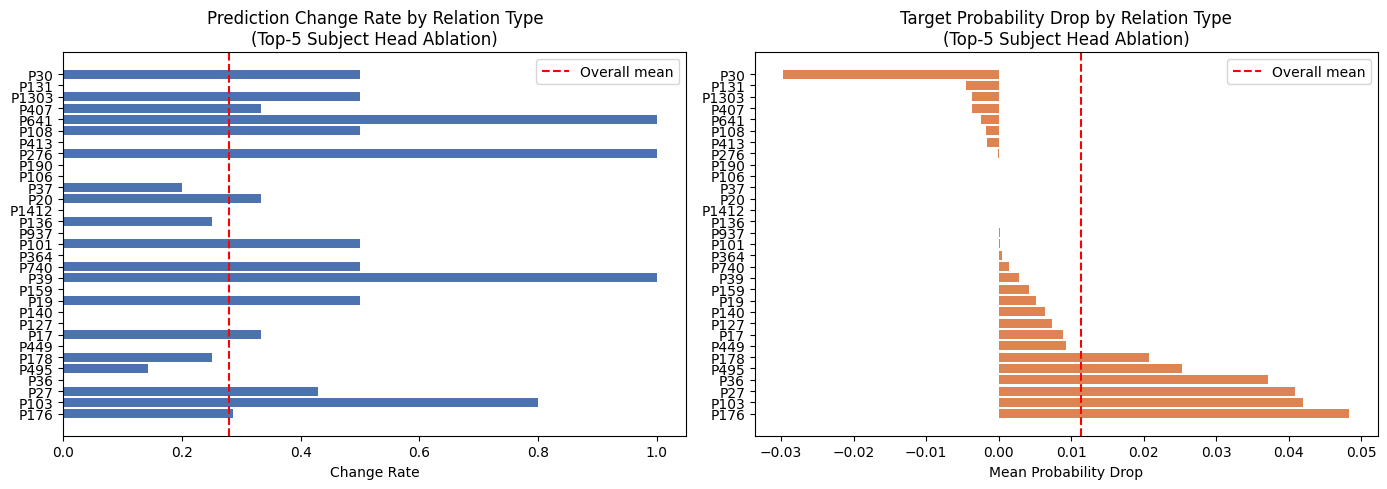

In [ ]:
# Does subject-focused head ablation affect some relation types more than others?

print("=" * 55)
print("RELATION TYPE ANALYSIS")
print("=" * 55)

k5_df = topk_df[topk_df["top_k"] == 5].copy()

relation_summary = k5_df.groupby("relation_id").agg(
    n             =("sample_id",      "count"),
    change_rate   =("changed",        "mean"),
    mean_prob_drop=("probability_drop","mean"),
    mean_logit_drop=("logit_drop",    "mean"),
    mean_rank_drop=("rank_drop",      "mean"),
    mean_kl       =("kl_divergence",  "mean"),
).reset_index().sort_values("mean_prob_drop", ascending=False)

relation_summary.to_csv("results/relation_type_summary.csv", index=False)
print(relation_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(relation_summary["relation_id"], relation_summary["change_rate"], color="#4C72B0")
axes[0].set_xlabel("Change Rate")
axes[0].set_title("Prediction Change Rate by Relation Type\n(Top-5 Subject Head Ablation)")
axes[0].axvline(k5_df["changed"].mean(), color="red", linestyle="--", label="Overall mean")
axes[0].legend()

axes[1].barh(relation_summary["relation_id"], relation_summary["mean_prob_drop"], color="#DD8452")
axes[1].set_xlabel("Mean Probability Drop")
axes[1].set_title("Target Probability Drop by Relation Type\n(Top-5 Subject Head Ablation)")
axes[1].axvline(k5_df["probability_drop"].mean(), color="red", linestyle="--", label="Overall mean")
axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/figures/relation_type_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

## Comparison summary table

,ablation_type,n,change_rate,mean_prob_drop,mean_logit_drop,mean_rank_drop,mean_kl
0,subject_top5,100,0.28,0.011340,0.549035,331.86,0.330187
1,subject_top10,100,0.34,0.016946,1.660315,826.85,0.760212
2,random_top5,100,0.15,0.003384,0.168343,227.48,0.097656
3,random_top10,100,0.27,0.014035,0.398732,334.51,0.341844
4,low_top5,100,0.19,0.001639,0.339726,-53.26,0.077133
5,low_top10,100,0.32,-0.019873,0.440539,212.04,0.399647


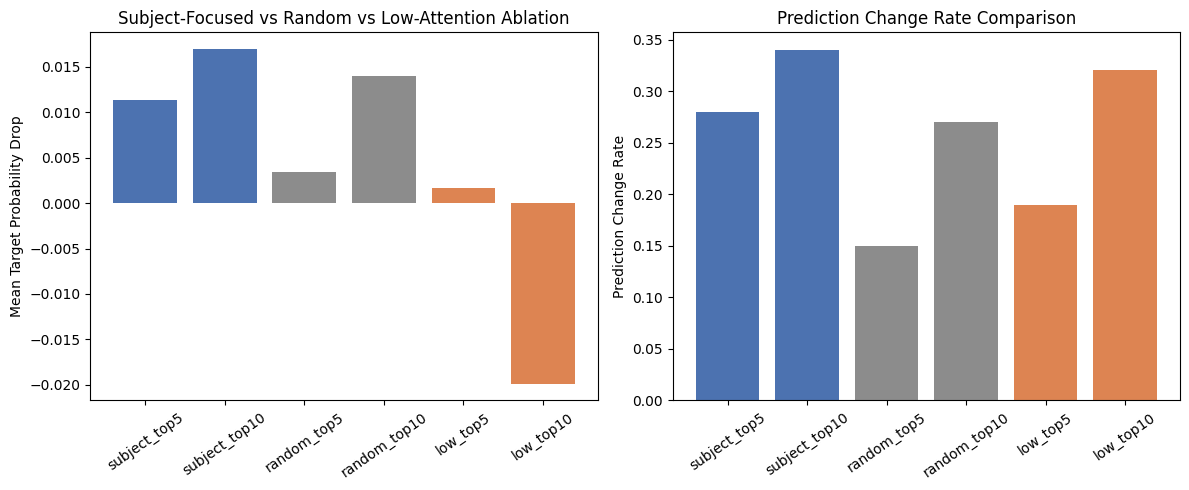

In [ ]:
# Combine subject-focused, random, and low-attention ablations
# into a single table and figure for easy comparison.

shared_cols = ["sample_id", "gpt2_correct", "relation_id",
               "changed", "probability_drop", "logit_drop",
               "rank_drop", "kl_divergence", "ablation_type"]

subject5  = topk_df[topk_df["top_k"] == 5].copy();  subject5["ablation_type"]  = "subject_top5"
subject10 = topk_df[topk_df["top_k"] == 10].copy(); subject10["ablation_type"] = "subject_top10"
rand5     = random_df[random_df["k"] == 5].copy()
rand10    = random_df[random_df["k"] == 10].copy()
low5      = low_df[low_df["k"] == 5].copy()
low10     = low_df[low_df["k"] == 10].copy()

comparison_df = pd.concat(
    [subject5[shared_cols], subject10[shared_cols],
     rand5[shared_cols],    rand10[shared_cols],
     low5[shared_cols],     low10[shared_cols]],
    ignore_index=True
)
comparison_df.to_csv("outputs/tables/ablation_comparison.csv", index=False)

comp_summary = comparison_df.groupby("ablation_type").agg(
    n              =("sample_id",       "count"),
    change_rate    =("changed",         "mean"),
    mean_prob_drop =("probability_drop","mean"),
    mean_logit_drop=("logit_drop",      "mean"),
    mean_rank_drop =("rank_drop",       "mean"),
    mean_kl        =("kl_divergence",   "mean"),
).reset_index()

ORDER = ["subject_top5","subject_top10","random_top5","random_top10","low_top5","low_top10"]
comp_summary["ablation_type"] = pd.Categorical(
    comp_summary["ablation_type"], categories=ORDER, ordered=True)
comp_summary = comp_summary.sort_values("ablation_type").reset_index(drop=True)
comp_summary.to_csv("results/control_comparison_summary.csv", index=False)
display(comp_summary)

colors = ["#4C72B0" if "subject" in t else
          "#8C8C8C" if "random"  in t else
          "#DD8452" for t in comp_summary["ablation_type"].astype(str)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comp_summary["ablation_type"].astype(str), comp_summary["mean_prob_drop"], color=colors)
axes[0].set_ylabel("Mean Target Probability Drop")
axes[0].set_title("Subject-Focused vs Random vs Low-Attention Ablation")
axes[0].tick_params(axis='x', rotation=35)

axes[1].bar(comp_summary["ablation_type"].astype(str), comp_summary["change_rate"], color=colors)
axes[1].set_ylabel("Prediction Change Rate")
axes[1].set_title("Prediction Change Rate Comparison")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig("outputs/figures/ablation_control_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Layer x Head subject attention heatmap

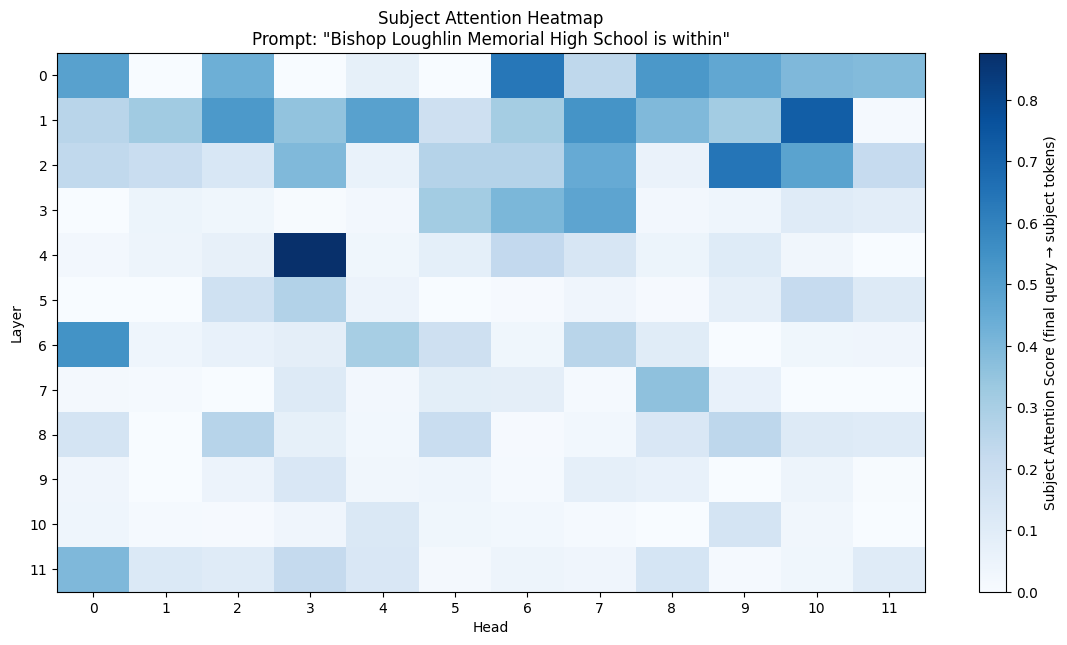

In [ ]:
# Visualize how strongly each (layer, head) attends to the subject
# entity tokens for the first sample in the dataset.

sample_0   = get_sample(0)
tokens_0   = model.to_tokens(sample_0["prompt"])
_, cache_0 = model.run_with_cache(tokens_0)
subj_idx_0 = get_subject_token_indices(sample_0["prompt"], sample_0["subject"])

heat = np.zeros((model.cfg.n_layers, model.cfg.n_heads))
for layer in range(model.cfg.n_layers):
    attn = cache_0[f"blocks.{layer}.attn.hook_pattern"][0]
    for head in range(model.cfg.n_heads):
        if subj_idx_0:
            heat[layer, head] = attn[head][-1].detach().cpu()[subj_idx_0].sum().item()

plt.figure(figsize=(14, 7))
plt.imshow(heat, aspect="auto", cmap="Blues")
plt.colorbar(label="Subject Attention Score (final query → subject tokens)")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.title(f"Subject Attention Heatmap\nPrompt: \"{sample_0['prompt']}\"")
plt.xticks(range(model.cfg.n_heads))
plt.yticks(range(model.cfg.n_layers))
plt.savefig("outputs/figures/subject_attention_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## Scatter — subject attention score vs prob drop

Scatter data:   0%|          | 0/100 [00:00<?, ?it/s]

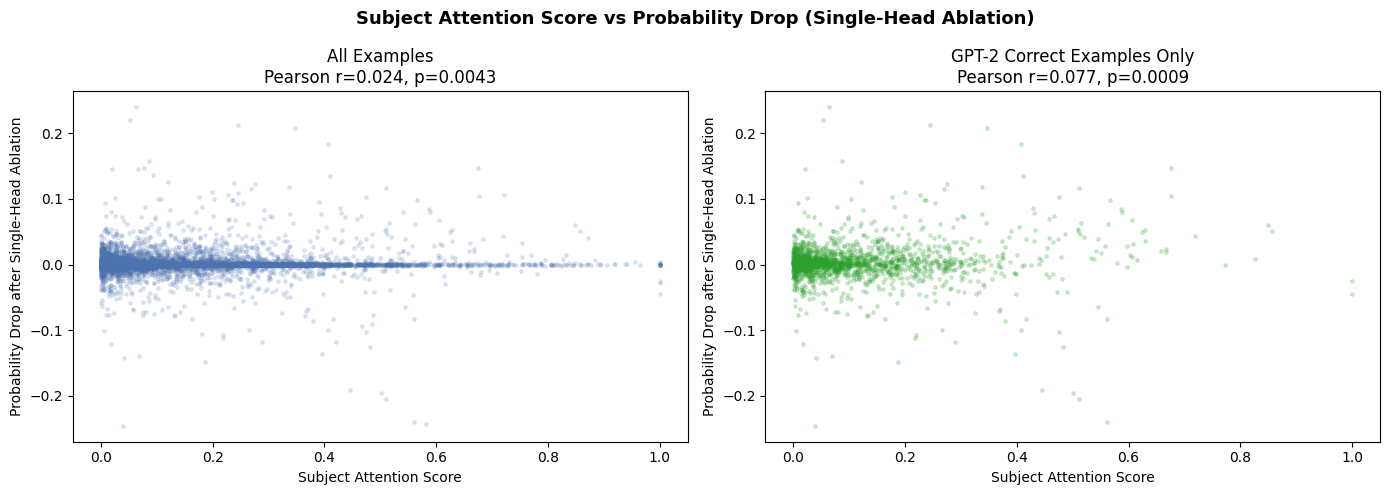

In [ ]:
# Key research question: does high subject attention actually predict
# causal importance? If yes, we expect a positive correlation.
# Each point is a single (sample, layer, head) triplet.

scatter_records = []

for i in tqdm(range(NUM_SAMPLES), desc="Scatter data"):
    s  = get_sample(i)
    bl = baseline_df[baseline_df["sample_id"] == i].iloc[0]

    df_rank = _rank_heads_by_subject(s["prompt"], s["subject"])
    if df_rank is None:
        continue

    baseline_logits = model(model.to_tokens(s["prompt"]))

    for _, row in df_rank.iterrows():
        layer, head, score = int(row["layer"]), int(row["head"]), row["score"]
        abl      = ablate_heads_and_get_logits(s["prompt"], [(layer, head)])
        abl_prob, _ = get_target_prob_from_logits(model, abl, s["target_true"])
        scatter_records.append({
            "sample_id":              i,
            "layer":                  layer,
            "head":                   head,
            "subject_attention_score": score,
            "probability_drop":        bl["target_true_prob"] - abl_prob,
            "relation_id":             s["relation_id"],
            "gpt2_correct":            bl["gpt2_correct"],
        })

scatter_df = pd.DataFrame(scatter_records)
scatter_df.to_csv("outputs/tables/scatter_attention_vs_probdrop.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All samples
axes[0].scatter(scatter_df["subject_attention_score"],
                scatter_df["probability_drop"],
                alpha=0.15, s=6, color="#4C72B0")
r, p = stats.pearsonr(scatter_df["subject_attention_score"],
                       scatter_df["probability_drop"])
axes[0].set_xlabel("Subject Attention Score")
axes[0].set_ylabel("Probability Drop after Single-Head Ablation")
axes[0].set_title(f"All Examples\nPearson r={r:.3f}, p={p:.4f}")

# GPT-2 correct examples only
correct_scatter = scatter_df[scatter_df["gpt2_correct"]]
axes[1].scatter(correct_scatter["subject_attention_score"],
                correct_scatter["probability_drop"],
                alpha=0.2, s=6, color="#2ca02c")
if len(correct_scatter) > 1:
    r2, p2 = stats.pearsonr(correct_scatter["subject_attention_score"],
                              correct_scatter["probability_drop"])
    axes[1].set_title(f"GPT-2 Correct Examples Only\nPearson r={r2:.3f}, p={p2:.4f}")

axes[1].set_xlabel("Subject Attention Score")
axes[1].set_ylabel("Probability Drop after Single-Head Ablation")

plt.suptitle("Subject Attention Score vs Probability Drop (Single-Head Ablation)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/figures/scatter_attention_vs_probdrop.png", dpi=300, bbox_inches="tight")
plt.show()

## Head-level activation patching

Patching: French:   0%|          | 0/12 [00:00<?, ?it/s]

Patching: Paris:   0%|          | 0/12 [00:00<?, ?it/s]

Patching: Apple:   0%|          | 0/12 [00:00<?, ?it/s]

Saved: outputs/tables/head_activation_patching.csv


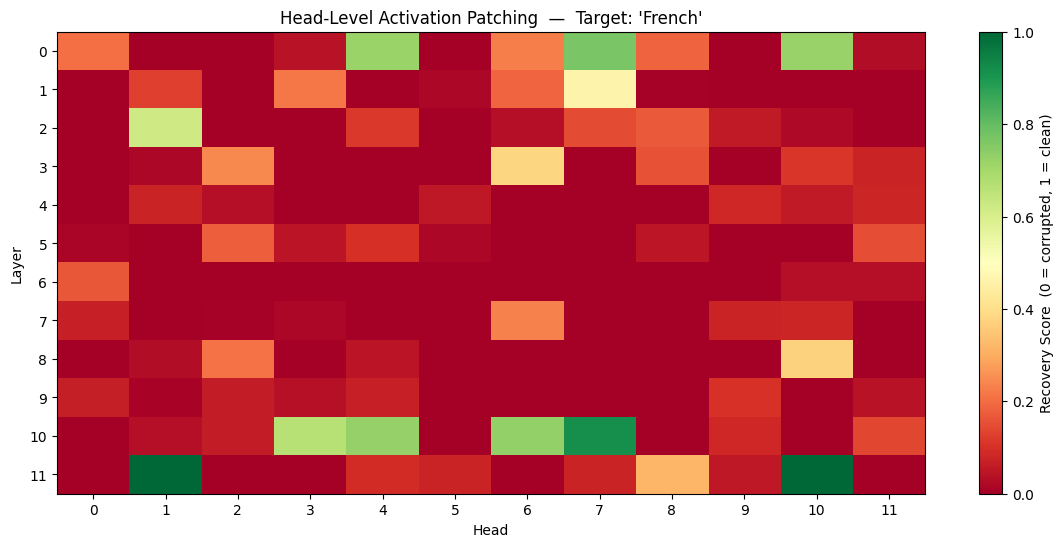

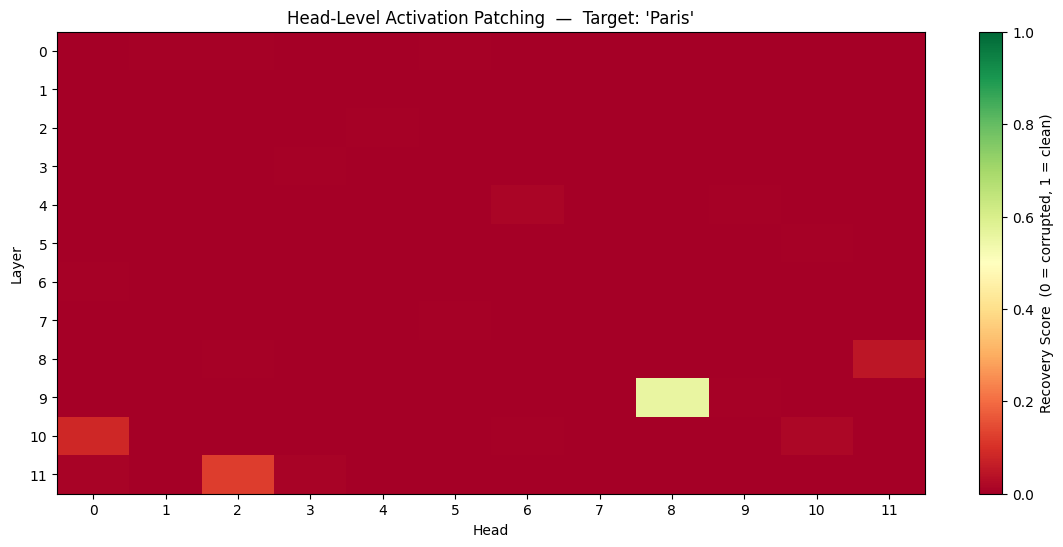

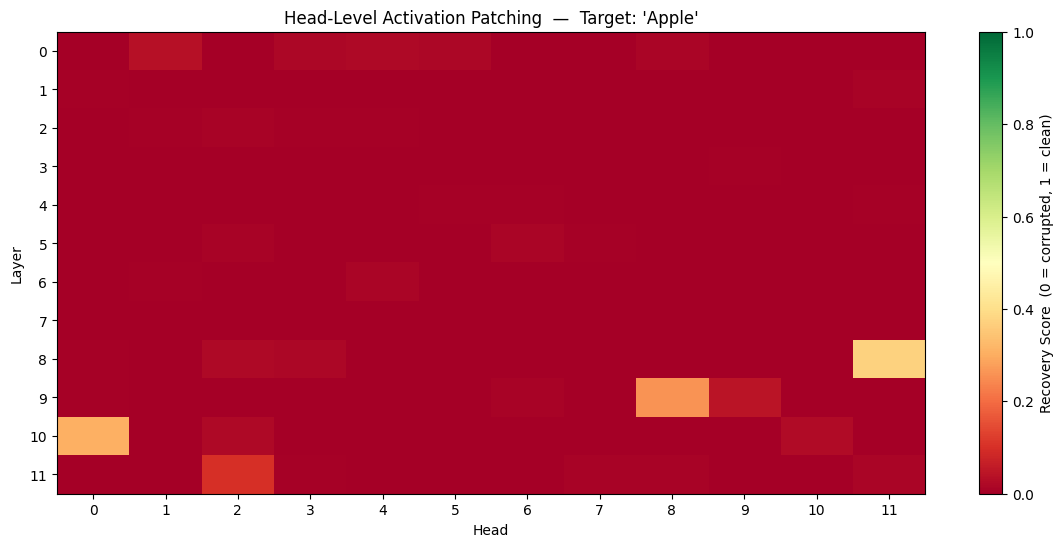


Top causal heads by recovery score:


,target,layer,head,recovery_score,patched_prob,clean_prob
0,French,11,10,1.197060,0.072571,0.074442
1,French,11,1,1.034252,0.074116,0.074442
2,French,10,7,0.915274,0.075246,0.074442
3,French,0,7,0.766831,0.076655,0.074442
4,French,10,6,0.728680,0.077018,0.074442
5,Paris,9,8,0.557736,0.001005,0.001629
6,Apple,8,11,0.373830,0.028265,0.062003
7,Apple,10,0,0.305082,0.024560,0.062003
8,Apple,9,8,0.259338,0.022096,0.062003
9,Paris,11,2,0.121935,0.000391,0.001629


In [ ]:
# For each (layer, head), copy its output from a clean run into a
# corrupted run and measure how much of the target probability is
# recovered. Recovery score of 1.0 means that head alone carries
# all the factual information needed to restore the correct answer.

def head_activation_patching(clean_prompt, corrupted_prompt, target, layer, head):
    clean_tokens     = model.to_tokens(clean_prompt)
    corrupted_tokens = model.to_tokens(corrupted_prompt)

    if clean_tokens.shape != corrupted_tokens.shape:
        return None

    # Single forward pass for clean — get both logits and cache
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    clean_z = clean_cache[f"blocks.{layer}.attn.hook_z"].clone()

    # Single forward pass for corrupted
    corrupted_logits, _ = model.run_with_cache(corrupted_tokens)

    def patch_fn(value, hook):
        value[:, :, head, :] = clean_z[:, :, head, :]
        return value

    patched_logits = model.run_with_hooks(
        corrupted_tokens,
        fwd_hooks=[(f"blocks.{layer}.attn.hook_z", patch_fn)]
    )

    cp,  _ = get_target_prob_from_logits(model, clean_logits,     target)
    crp, _ = get_target_prob_from_logits(model, corrupted_logits, target)
    pp,  _ = get_target_prob_from_logits(model, patched_logits,   target)

    denom    = cp - crp
    recovery = (pp - crp) / denom if abs(denom) > 1e-6 else 0.0

    return {
        "layer": layer, "head": head,
        "clean_prob": cp, "corrupted_prob": crp, "patched_prob": pp,
        "recovery_score": recovery,
    }

PATCH_SAMPLES = [

    {"clean":     "The mother tongue of Victor Hugo is",
     "corrupted": "The mother tongue of Albert Einstein is",
     "target":    "French"},

    {"clean":     "The capital of France is",
     "corrupted": "The capital of Germany is",
     "target":    "Paris"},

    {"clean":     "The Apple A5 chip was made by",
     "corrupted": "The Galaxy S5 chip was made by",
     "target":    "Apple"},
]
all_patch = []
for sp in PATCH_SAMPLES:
    for layer in tqdm(range(model.cfg.n_layers), desc=f"Patching: {sp['target']}"):
        for head in range(model.cfg.n_heads):
            res = head_activation_patching(
                sp["clean"], sp["corrupted"], sp["target"], layer, head)
            if res is not None:
                res["target"] = sp["target"]
                all_patch.append(res)

patch_df = pd.DataFrame(all_patch)
patch_df.to_csv("outputs/tables/head_activation_patching.csv", index=False)
print("Saved: outputs/tables/head_activation_patching.csv")

# Recovery heatmap for each target
for target_name in patch_df["target"].unique():
    sub   = patch_df[patch_df["target"] == target_name]
    pivot = sub.pivot(index="layer", columns="head", values="recovery_score")

    plt.figure(figsize=(14, 6))
    plt.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    plt.colorbar(label="Recovery Score  (0 = corrupted, 1 = clean)")
    plt.xlabel("Head")
    plt.ylabel("Layer")
    plt.title(f"Head-Level Activation Patching  —  Target: '{target_name}'")
    plt.xticks(range(model.cfg.n_heads))
    plt.yticks(range(model.cfg.n_layers))
    plt.savefig(f"outputs/figures/head_patching_{target_name.lower()}.png",
                dpi=300, bbox_inches="tight")
    plt.show()

# Top heads by recovery score
top_causal = (
    patch_df.sort_values("recovery_score", ascending=False)
    .groupby("target").head(5)
    [["target","layer","head","recovery_score","patched_prob","clean_prob"]]
    .reset_index(drop=True)
)
top_causal.to_csv("outputs/tables/top_causal_heads.csv", index=False)
print("\nTop causal heads by recovery score:")
display(top_causal)

In [ ]:
# Layer-position causal tracing via residual stream patching.
# For each layer and token position, copy clean residual activation
# into the corrupted run and measure target probability recovery.

def residual_position_patching(clean_prompt, corrupted_prompt, target, layer, pos):
    clean_tokens = model.to_tokens(clean_prompt)
    corrupted_tokens = model.to_tokens(corrupted_prompt)

    if clean_tokens.shape != corrupted_tokens.shape:
        return None

    hook_name = f"blocks.{layer}.hook_resid_pre"

    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits = model(corrupted_tokens)

    clean_resid = clean_cache[hook_name].clone()

    def patch_fn(value, hook):
        # value shape: [batch, seq_len, d_model]
        value[:, pos, :] = clean_resid[:, pos, :]
        return value

    patched_logits = model.run_with_hooks(
        corrupted_tokens,
        fwd_hooks=[(hook_name, patch_fn)]
    )

    clean_prob, _ = get_target_prob_from_logits(model, clean_logits, target)
    corrupted_prob, _ = get_target_prob_from_logits(model, corrupted_logits, target)
    patched_prob, _ = get_target_prob_from_logits(model, patched_logits, target)

    denom = clean_prob - corrupted_prob
    recovery = (patched_prob - corrupted_prob) / denom if abs(denom) > 1e-6 else 0.0

    return {
        "layer": layer,
        "position": pos,
        "clean_prob": clean_prob,
        "corrupted_prob": corrupted_prob,
        "patched_prob": patched_prob,
        "recovery_score": recovery,
    }


causal_records = []

for sp in PATCH_SAMPLES:
    clean_tokens = model.to_tokens(sp["clean"])
    corrupted_tokens = model.to_tokens(sp["corrupted"])

    if clean_tokens.shape != corrupted_tokens.shape:
        print("Skipping due to token length mismatch:")
        print("Clean:", sp["clean"])
        print("Corrupted:", sp["corrupted"])
        continue

    clean_token_labels = model.to_str_tokens(sp["clean"])

    for layer in tqdm(range(model.cfg.n_layers), desc=f"Causal tracing: {sp['target']}"):
        for pos in range(clean_tokens.shape[1]):
            res = residual_position_patching(
                sp["clean"],
                sp["corrupted"],
                sp["target"],
                layer,
                pos
            )

            if res is not None:
                res["target"] = sp["target"]
                res["clean_prompt"] = sp["clean"]
                res["corrupted_prompt"] = sp["corrupted"]
                res["token"] = clean_token_labels[pos]
                causal_records.append(res)

causal_df = pd.DataFrame(causal_records)
causal_df.to_csv("outputs/tables/causal_tracing_residual_patching.csv", index=False)

print("Saved: outputs/tables/causal_tracing_residual_patching.csv")
display(causal_df.head())

Causal tracing: French:   0%|          | 0/12 [00:00<?, ?it/s]

Causal tracing: Paris:   0%|          | 0/12 [00:00<?, ?it/s]

Causal tracing: Apple:   0%|          | 0/12 [00:00<?, ?it/s]

Saved: outputs/tables/causal_tracing_residual_patching.csv


,layer,position,clean_prob,corrupted_prob,patched_prob,recovery_score,target,clean_prompt,corrupted_prompt,token
0,0,0,0.074442,0.083936,0.083936,-0.0,French,The mother tongue of Victor Hugo is,The mother tongue of Albert Einstein is,<|endoftext|>
1,0,1,0.074442,0.083936,0.083936,-0.0,French,The mother tongue of Victor Hugo is,The mother tongue of Albert Einstein is,The
2,0,2,0.074442,0.083936,0.083936,-0.0,French,The mother tongue of Victor Hugo is,The mother tongue of Albert Einstein is,mother
3,0,3,0.074442,0.083936,0.083936,-0.0,French,The mother tongue of Victor Hugo is,The mother tongue of Albert Einstein is,tongue
4,0,4,0.074442,0.083936,0.083936,-0.0,French,The mother tongue of Victor Hugo is,The mother tongue of Albert Einstein is,of


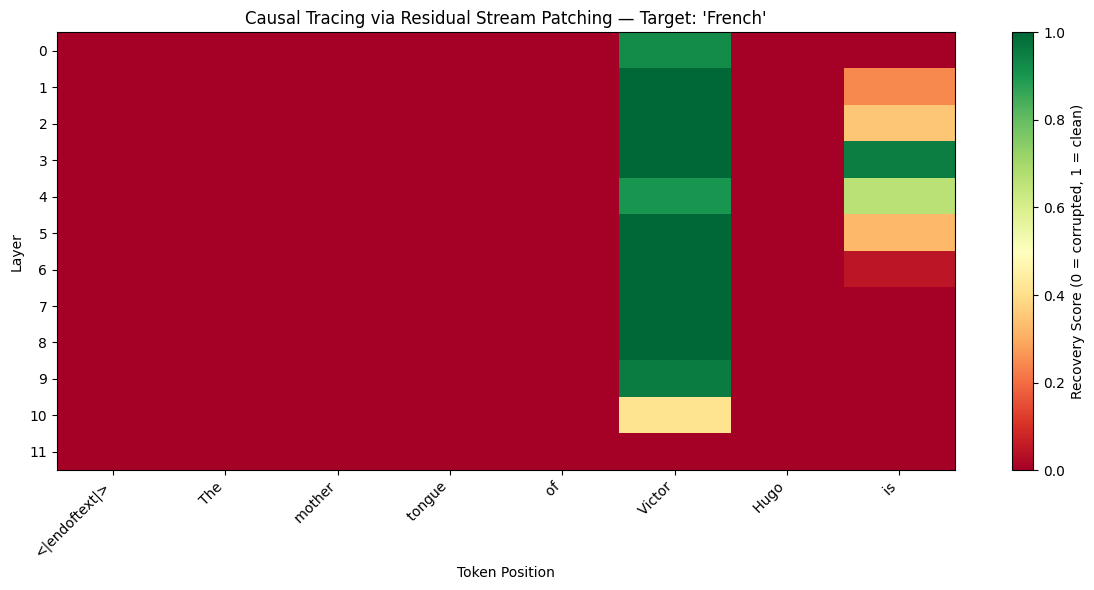

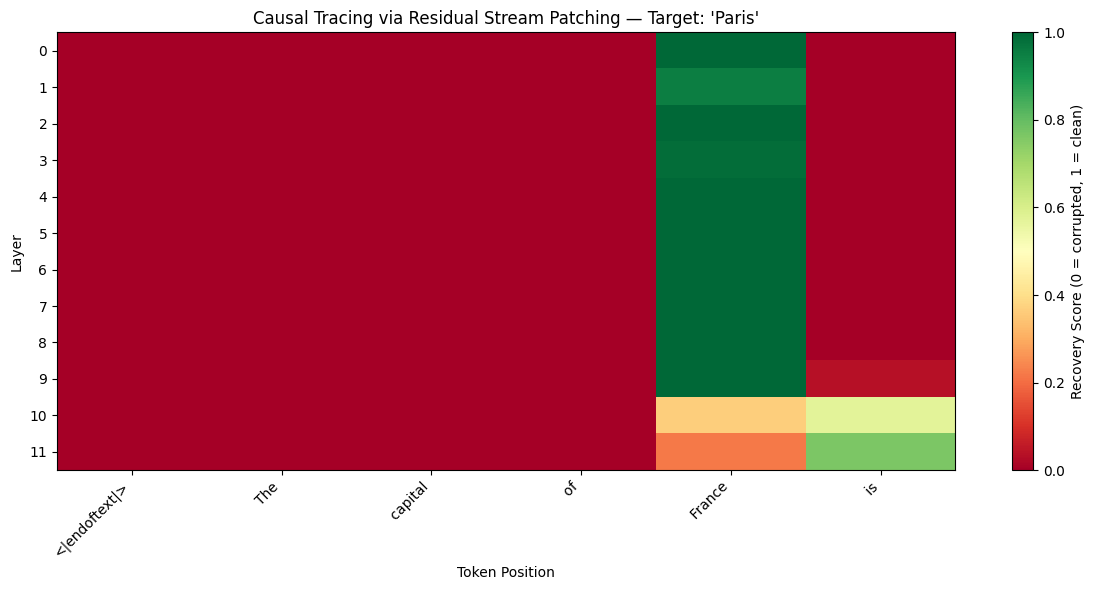

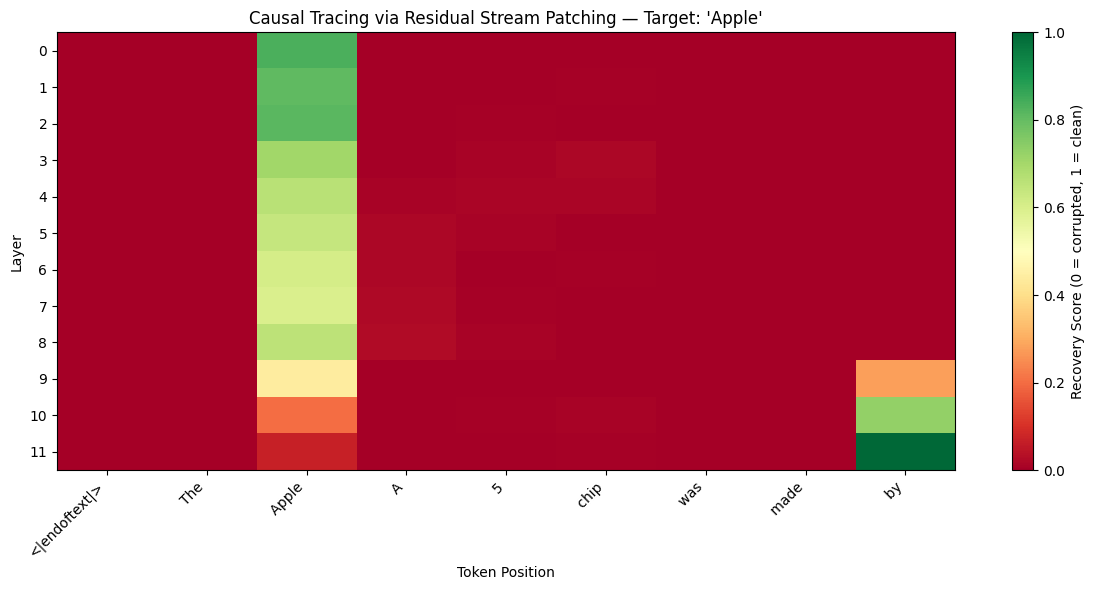

In [ ]:
# Plot causal tracing heatmaps.

for target_name in causal_df["target"].unique():
    sub = causal_df[causal_df["target"] == target_name].copy()

    pivot = sub.pivot(index="layer", columns="position", values="recovery_score")
    token_labels = (
        sub.sort_values("position")
           .drop_duplicates("position")["token"]
           .tolist()
    )

    plt.figure(figsize=(12, 6))
    plt.imshow(pivot.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    plt.colorbar(label="Recovery Score (0 = corrupted, 1 = clean)")
    plt.xlabel("Token Position")
    plt.ylabel("Layer")
    plt.title(f"Causal Tracing via Residual Stream Patching — Target: '{target_name}'")
    plt.xticks(range(len(token_labels)), token_labels, rotation=45, ha="right")
    plt.yticks(range(model.cfg.n_layers))
    plt.tight_layout()
    plt.savefig(
        f"outputs/figures/causal_tracing_{target_name.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [ ]:
top_causal_trace = (
    causal_df.sort_values("recovery_score", ascending=False)
    .groupby("target")
    .head(10)
    [[
        "target",
        "layer",
        "position",
        "token",
        "recovery_score",
        "corrupted_prob",
        "patched_prob",
        "clean_prob"
    ]]
    .reset_index(drop=True)
)

top_causal_trace.to_csv("outputs/tables/top_causal_tracing_positions.csv", index=False)
display(top_causal_trace)

,target,layer,position,token,recovery_score,corrupted_prob,patched_prob,clean_prob
0,French,1,5,Victor,1.275840,0.083936,0.071823,0.074442
1,French,7,5,Victor,1.249758,0.083936,0.072070,0.074442
2,French,2,5,Victor,1.223597,0.083936,0.072319,0.074442
3,Paris,7,4,France,1.197231,0.000219,0.001907,0.001629
4,Apple,11,8,by,1.192336,0.008122,0.072366,0.062003
5,French,8,5,Victor,1.187124,0.083936,0.072665,0.074442
6,Paris,9,4,France,1.170600,0.000219,0.001870,0.001629
7,Paris,8,4,France,1.138516,0.000219,0.001824,0.001629
8,French,5,5,Victor,1.101518,0.083936,0.073478,0.074442
9,French,6,5,Victor,1.089857,0.083936,0.073588,0.074442


## Statistical significance tests

In [ ]:
# Chi-square tests for prediction change rates,
# Mann-Whitney U and Wilcoxon signed-rank for probability drops,
# and bootstrap 95% confidence intervals.

print("=" * 55)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 55)

s5  = topk_df[topk_df["top_k"] == 5]
s10 = topk_df[topk_df["top_k"] == 10]
r5  = random_df[random_df["k"] == 5]
r10 = random_df[random_df["k"] == 10]
l5  = low_df[low_df["k"] == 5]
l10 = low_df[low_df["k"] == 10]

def chi2_test(a_changed, b_changed, label):
    n_a, n_b = len(a_changed), len(b_changed)
    table = [
        [int(a_changed.sum()), n_a - int(a_changed.sum())],
        [int(b_changed.sum()), n_b - int(b_changed.sum())],
    ]
    chi2, p, _, _ = stats.chi2_contingency(table)
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {label:40s} chi2={chi2:.3f}  p={p:.4f}  [{sig}]")

print("\n[Chi-square — prediction change rate]")
chi2_test(s5["changed"],  r5["changed"],  "Subject-Top5  vs Random-Top5")
chi2_test(s5["changed"],  l5["changed"],  "Subject-Top5  vs Low-Top5")
chi2_test(s10["changed"], r10["changed"], "Subject-Top10 vs Random-Top10")
chi2_test(s10["changed"], l10["changed"], "Subject-Top10 vs Low-Top10")

def mwu_test(a, b, label):
    u, p = stats.mannwhitneyu(a, b, alternative="greater")
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {label:40s} U={u:.1f}  p={p:.4f}  [{sig}]")

print("\n[Mann-Whitney U — probability drop (subject > other)]")
mwu_test(s5["probability_drop"],  r5["probability_drop"],  "Subject-Top5  vs Random-Top5")
mwu_test(s5["probability_drop"],  l5["probability_drop"],  "Subject-Top5  vs Low-Top5")
mwu_test(s10["probability_drop"], r10["probability_drop"], "Subject-Top10 vs Random-Top10")
mwu_test(s10["probability_drop"], l10["probability_drop"], "Subject-Top10 vs Low-Top10")

def wilcoxon_test(a, b, label):
    merged = a.merge(b, on="sample_id", suffixes=("_a", "_b"))
    if len(merged) < 5:
        print(f"  {label:40s} insufficient overlapping samples ({len(merged)})")
        return
    stat, p = stats.wilcoxon(merged["probability_drop_a"], merged["probability_drop_b"])
    sig = "significant" if p < 0.05 else "not significant"
    print(f"  {label:40s} W={stat:.1f}  p={p:.4f}  [{sig}]  n={len(merged)}")

print("\n[Wilcoxon Signed-Rank — paired probability drop]")
wilcoxon_test(s5[["sample_id","probability_drop"]],
              r5[["sample_id","probability_drop"]],
              "Subject-Top5 vs Random-Top5")
wilcoxon_test(s5[["sample_id","probability_drop"]],
              l5[["sample_id","probability_drop"]],
              "Subject-Top5 vs Low-Top5")

def bootstrap_ci(values, n_boot=2000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(values, size=len(values), replace=True).mean()
                  for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(values), lo, hi

print("\n[Bootstrap 95% CI — mean probability drop]")
for label, arr in [
    ("Subject-Top5",  s5["probability_drop"].values),
    ("Subject-Top10", s10["probability_drop"].values),
    ("Random-Top5",   r5["probability_drop"].values),
    ("Low-Top5",      l5["probability_drop"].values),
]:
    mean, lo, hi = bootstrap_ci(arr)
    print(f"  {label:20s}  mean={mean:.4f}  95% CI=[{lo:.4f}, {hi:.4f}]")

# Save statistical summary
stat_rows = []
for label, arr_s, arr_r in [
    ("top5",  s5["probability_drop"].values,  r5["probability_drop"].values),
    ("top10", s10["probability_drop"].values, r10["probability_drop"].values),
]:
    u, p_mw = stats.mannwhitneyu(arr_s, arr_r, alternative="greater")
    m_s, lo_s, hi_s = bootstrap_ci(arr_s)
    m_r, lo_r, hi_r = bootstrap_ci(arr_r)
    stat_rows.append({
        "comparison":            f"subject_{label}_vs_random_{label}",
        "subject_mean_prob_drop": m_s,
        "subject_ci_lo":          lo_s,
        "subject_ci_hi":          hi_s,
        "random_mean_prob_drop":  m_r,
        "random_ci_lo":           lo_r,
        "random_ci_hi":           hi_r,
        "mwu_p":                  p_mw,
        "significant":            p_mw < 0.05,
    })

stat_summary_df = pd.DataFrame(stat_rows)
stat_summary_df.to_csv("results/statistical_tests.csv", index=False)
display(stat_summary_df)

STATISTICAL SIGNIFICANCE TESTS

[Chi-square — prediction change rate]
  Subject-Top5  vs Random-Top5             chi2=4.266  p=0.0389  [significant]
  Subject-Top5  vs Low-Top5                chi2=1.780  p=0.1821  [not significant]
  Subject-Top10 vs Random-Top10            chi2=0.849  p=0.3568  [not significant]
  Subject-Top10 vs Low-Top10               chi2=0.023  p=0.8805  [not significant]

[Mann-Whitney U — probability drop (subject > other)]
  Subject-Top5  vs Random-Top5             U=5719.0  p=0.0396  [significant]
  Subject-Top5  vs Low-Top5                U=5791.0  p=0.0267  [significant]
  Subject-Top10 vs Random-Top10            U=4895.0  p=0.6017  [not significant]
  Subject-Top10 vs Low-Top10               U=6309.0  p=0.0007  [significant]

[Wilcoxon Signed-Rank — paired probability drop]
  Subject-Top5 vs Random-Top5              W=1883.0  p=0.0273  [significant]  n=100
  Subject-Top5 vs Low-Top5                 W=1563.0  p=0.0009  [significant]  n=100

[Bootstrap 95% C

,comparison,subject_mean_prob_drop,subject_ci_lo,subject_ci_hi,random_mean_prob_drop,random_ci_lo,random_ci_hi,mwu_p,significant
0,subject_top5_vs_random_top5,0.011340,0.004640,0.018855,0.003384,-0.000092,0.007187,0.039581,True
1,subject_top10_vs_random_top10,0.016946,0.007785,0.026905,0.014035,0.007388,0.022384,0.601711,False


## Probability drop distribution plot

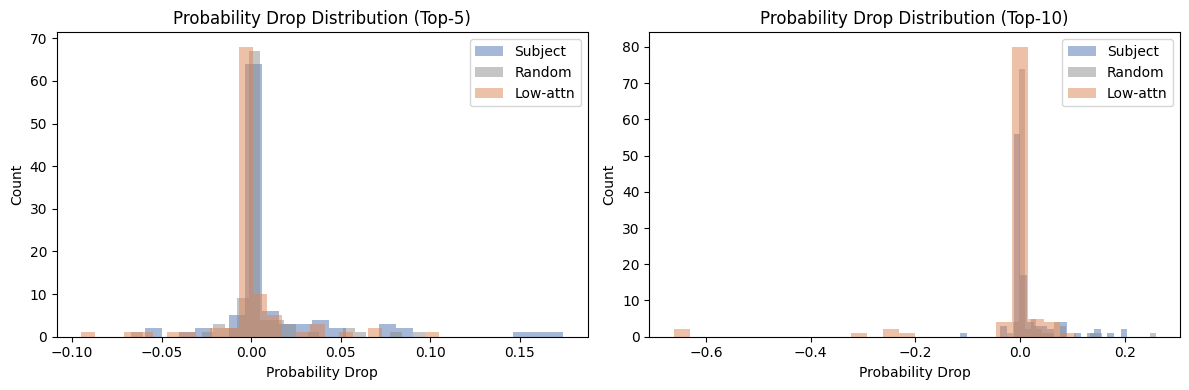

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, sub_k, rand_k, low_k, title in [
    (axes[0], s5,  r5,  l5,  "Top-5"),
    (axes[1], s10, r10, l10, "Top-10"),
]:
    ax.hist(sub_k["probability_drop"],  bins=25, alpha=0.5, label="Subject", color="#4C72B0")
    ax.hist(rand_k["probability_drop"], bins=25, alpha=0.5, label="Random",  color="#8C8C8C")
    ax.hist(low_k["probability_drop"],  bins=25, alpha=0.5, label="Low-attn",color="#DD8452")
    ax.set_xlabel("Probability Drop")
    ax.set_ylabel("Count")
    ax.set_title(f"Probability Drop Distribution ({title})")
    ax.legend()

plt.tight_layout()
plt.savefig("outputs/figures/prob_drop_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Final artifact listing

In [ ]:
print("outputs/")
for root, _, files in os.walk("outputs"):
    level = root.replace("outputs","").count(os.sep)
    print("    " * level + os.path.basename(root) + "/")
    for f in sorted(files):
        print("    " * (level+1) + f)

print("\nresults/")
for f in sorted(os.listdir("results")):
    print("   ", f)

outputs/
outputs/
    tables/
        ablation_comparison.csv
        baseline_stats.csv
        causal_tracing_residual_patching.csv
        head_activation_patching.csv
        low_ablation_results.csv
        random_ablation_results.csv
        scatter_attention_vs_probdrop.csv
        top_causal_heads.csv
        top_causal_tracing_positions.csv
        topk_ablation_results.csv
    figures/
        ablation_control_comparison.png
        causal_tracing_apple.png
        causal_tracing_french.png
        causal_tracing_paris.png
        head_patching_apple.png
        head_patching_french.png
        head_patching_paris.png
        prob_drop_distribution.png
        relation_type_analysis.png
        scatter_attention_vs_probdrop.png
        subject_attention_heatmap.png

results/
    control_comparison_summary.csv
    filtering_summary.csv
    relation_type_summary.csv
    statistical_tests.csv
